# RTDA — latency, II and throughput, with the host taken out

`rtda_scan.ipynb` measures **wall-clock on the host**: every number there is "µs per event"
at some batch size, with the XRT host included. That one label hides three different
quantities, and mixing them is what makes the comparison confusing. This notebook separates
them, and measures the accelerators **without the host** from cycle-accurate simulation
(AIE: aiesimulator + VCD + kernel profile; PL: RTL co-simulation).

## The four terms, used one way throughout

| Term | Definition | Unit here |
|---|---|---|
| **II** (initiation interval) | time between consecutive outputs in steady state | AIE: ns per iteration (8 tracks); PL: µs per track |
| **Throughput** | work per unit time in steady state = batch / II | µs per event, or events/s |
| **Latency** | time for **one** event, first track in → 128-wide mean out, on an idle device | µs |
| **Pipeline depth** | latency / II — how many batches are inside the device at once | iterations |

"Inference time" is avoided on purpose: it means latency at batch 1 and throughput at large
batch, and those differ by 4× on the AIE.

## Where each number comes from

```
us_total      host program: staging + everything below          ┐
 └ us_execute XRT: sync + kernel                                 │ board, host_scan.exe
    └ us_kernel  graph.run()+wait() / xrt::run                   ┘
       └ DEVICE  array or fabric only                            ← aiesimulator / RTL cosim
```

The CPU and GPU have no device boundary to strip: their whole call is the computation.

In [1]:
import os, re, subprocess, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
pd.set_option('display.width', 160)

# RTDA_REPO points the notebook at a build tree from elsewhere; otherwise walk up
# from the notebook, the same rule as the other three notebooks.
REPO = Path(os.environ['RTDA_REPO']) if os.environ.get('RTDA_REPO') else Path.cwd()
while not (REPO / 'model' / 'weights_fp32').is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
RESULTS = REPO / 'results'
AIE     = REPO / 'aie_batch'
OUTD    = REPO / 'analysis' / 'out'
CACHE   = OUTD / 'timing_cache'
CACHE.mkdir(parents=True, exist_ok=True)
print('repo   :', REPO)

# The graph's own helpers, so the port layout, the T-marker rule and the output
# directory name are defined in one place and not re-spelled here.
sys.path.insert(0, str(AIE))
import aie_io, run_sim
from report import _TS, _TO_NS

# Same implementations, labels and colours as rtda_scan.ipynb / rtda_compare.ipynb.
IMPLS  = ('aie_fp32', 'aie_bf16', 'pl_fixed')
LABEL  = {'aie_fp32': 'AIE-ML fp32', 'aie_bf16': 'AIE-ML bf16', 'pl_fixed': 'FPGA fixed<16,3>'}
COL    = {'aie_fp32': '#1f77b4', 'aie_bf16': '#d62728', 'pl_fixed': '#9467bd'}
CPU_SHADE = {1: '#a1d99b', 8: '#41ab5d', 32: '#005a32'}
GPU_SHADE = {'fp32': '#f16913', 'bf16': '#8c2d04'}

TRACKS_PER_EVENT, ITER_PER_EVENT, BATCH = 50, 7, 8
SIM_EVENTS = 10                                   # make exactsim EVENTS=10 -> 77 iterations incl. flush
PRECISIONS = ('fp32', 'bf16')
LAYER = {f'L{i}Cfg': n for i, n in enumerate(
    ['emb_d0', 'emb_d1'] + [f's{s}_d{d}' for s in range(3) for d in range(4)], start=1)}

mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'savefig.facecolor': 'white', 'savefig.dpi': 150, 'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#9aa0a6', 'axes.labelcolor': '#202124',
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelsize': 9.5, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'xtick.color': '#5f6368', 'ytick.color': '#5f6368', 'text.color': '#202124',
    'grid.color': '#dadce0', 'grid.linewidth': 0.6, 'axes.grid': True,
    'axes.axisbelow': True, 'lines.linewidth': 2, 'lines.markersize': 6,
    'legend.frameon': False, 'legend.fontsize': 9,
    'figure.constrained_layout.use': True,
})

def style(ax, title=None, xlabel=None, ylabel=None, note=None):
    if title:  ax.set_title(title, pad=10)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if note:   ax.text(0.0, -0.19, note, transform=ax.transAxes, fontsize=8, color='#5f6368', va='top')
    return ax

FIGS = []
def save(fig, name):
    p = OUTD / name
    fig.savefig(p, bbox_inches='tight')
    if name not in FIGS:
        FIGS.append(name)
    print('  wrote', p.relative_to(REPO))

def md_table(df):
    cols = [str(c) for c in df.columns]
    out = ['| ' + ' | '.join(cols) + ' |', '|' + '|'.join('---' for _ in cols) + '|']
    for _, row in df.iterrows():
        out.append('| ' + ' | '.join(str(v) for v in row.tolist()) + ' |')
    return '\n'.join(out)

def read_kv(path):
    out = {}
    if not Path(path).exists():
        return out
    for line in Path(path).read_text().splitlines():
        if '=' in line:
            k, v = line.split('=', 1)
            out[k.strip()] = v.strip()
    return out

CHECKS = []
def check(name, got, want, tol_rel):
    ok = abs(got - want) <= tol_rel * abs(want)
    CHECKS.append((name, got, want, tol_rel, ok))
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}: {got:,.4g} vs {want:,.4g} "
          f"({100 * (got - want) / want:+.2f}%, tolerance {100 * tol_rel:.1f}%)")

repo   : /home/synthara/VersalPrjs/LDRD/final_rtda/rtda_demo


## 1. What ran

Every run below is checked for being the run it claims to be before anything is computed from it.

In [2]:
SIM = {}
rows = []
for P in PRECISIONS:
    work = f'Work_{P}_ev{SIM_EVENTS}'
    simd = run_sim.output_dir('aie', work)
    stamp = read_kv(simd / 'run_stamp.txt')
    log = AIE / f'run_{P}_ev{SIM_EVENTS}.log'
    verdict = worst = '?'
    if log.exists():
        txt = log.read_text(errors='replace')
        worst = (re.findall(r'worst event\s*:\s*\d+\s+max\|diff\| = (\S+)', txt) or ['?'])[-1]
        verdict = 'PASS' if re.search(r'^\s+PASS\s*$', txt, re.M) else 'no PASS line'
    if stamp.get('precision') not in (None, P):
        raise SystemExit(f'{simd.name} was produced by a {stamp["precision"]} run, not {P}')
    SIM[P] = dict(work=AIE / work, simd=simd, iterations=int(stamp.get('iterations', 0)),
                  events=AIE / f'trdata_{P}_ev{SIM_EVENTS}' / 'events.txt',
                  xpe=AIE / f'xpe_{P}_ev{SIM_EVENTS}' / 'app.xpe')
    rows.append(dict(run=f'aiesim {P}', what=f"{stamp.get('iterations','?')} iterations "
                     f"({SIM_EVENTS} events + 1 flush), {stamp.get('when','?')}",
                     accuracy=f'{verdict}, worst {worst}',
                     vcd_events='yes' if SIM[P]['events'].exists() else 'MISSING',
                     profiles=len(list(simd.glob('profile_funct_*.txt')))))

COSIM = {}
for ev in (1, 10):
    d = RESULTS / 'pl_fixed' / f'cosim_ev{ev}'
    rpt = d / 'rtda_split_top_cosim.rpt'
    if not rpt.exists():
        continue
    row = next(l for l in rpt.read_text().splitlines() if l.strip().startswith('|   Verilog'))
    c = [x.strip() for x in row.split('|')]
    log = next(d.glob('cosim_ev*.log'), None)
    txt = log.read_text(errors='replace') if log else ''
    tb = re.search(r'tb events\s*:\s*(\d+)', txt)
    if tb and int(tb.group(1)) != ev:
        raise SystemExit(f'{d.name}: its log says {tb.group(1)} events')
    COSIM[ev] = int(c[3])
    rows.append(dict(run=f'RTL cosim PL, {ev} event(s)', what=f'{c[2]}, latency {int(c[3]):,} cycles',
                     accuracy='PASS, 0.000e+00' if 'finished: PASS' in txt else '?',
                     vcd_events='-', profiles='-'))
display(pd.DataFrame(rows))

,run,what,accuracy,vcd_events,profiles
0,aiesim fp32,"77 iterations (10 events + 1 flush), 2026-09-1...","PASS, worst 6.495e-07",yes,122
1,aiesim bf16,"77 iterations (10 events + 1 flush), 2026-09-1...","PASS, worst 6.913e-04",yes,124
2,"RTL cosim PL, 1 event(s)","Pass, latency 68,981 cycles","PASS, 0.000e+00",-,-
3,"RTL cosim PL, 10 event(s)","Pass, latency 532,949 cycles","PASS, 0.000e+00",-,-


## 2. AIE: the II at every stage

The simulation build drains four stage outputs to PLIO debug taps (`ofm[0..7]`) plus the
event tail (`ofm[8]`), each line stamped with a `T <time>` marker. Two things are read here:
the **interval** at each stage, and each stage's **lag** behind the embedding output for the
same iteration.

If every stage has the same interval and the lags are constant, the pipeline is in steady state.

,precision,port,tensor,first_frame_us,ii_ns_it0_20,ii_ns_it20_end,lag_vs_emb_it0_us,lag_vs_emb_last_us
0,fp32,y_p0,emb_out[0],17.12,4172.0,4172.0,0.00,0.00
1,fp32,y_p1,emb_out[1],17.12,4172.0,4172.0,0.00,0.00
2,fp32,y_p2,s0_out[0],42.43,4172.0,4172.0,25.31,25.31
3,fp32,y_p3,s0_out[1],42.43,4172.0,4172.0,25.31,25.31
4,fp32,y_p4,s1_out[0],67.94,4172.0,4172.0,50.83,50.83
5,fp32,y_p5,s1_out[1],67.94,4172.0,4172.0,50.83,50.83
6,fp32,y_p6,s2_out[0],93.26,4176.8,4171.9,76.14,76.24
7,fp32,y_p7,s2_out[1],93.26,4176.8,4172.0,76.14,76.24
8,fp32,y_p8,track_out,95.57,4132.8,4171.9,78.45,77.67
9,bf16,y_p0,emb_out[0],8.80,924.8,924.8,0.00,0.00


  wrote analysis/out/timing_stage_lag_fp32.png


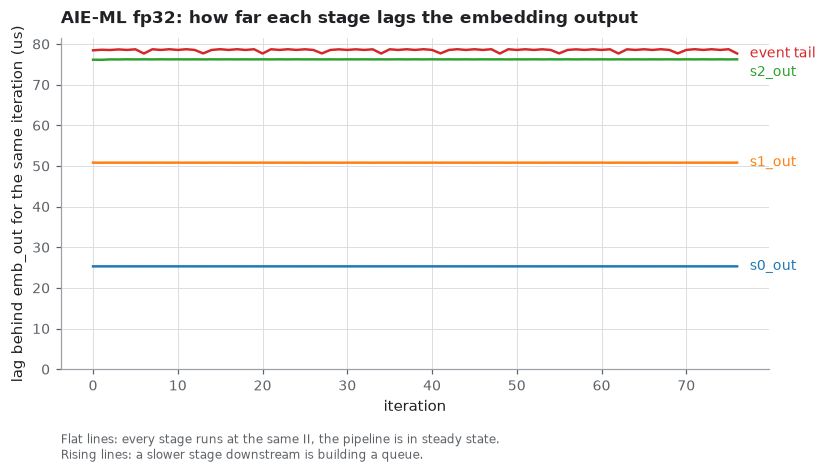

  wrote analysis/out/timing_stage_lag_bf16.png


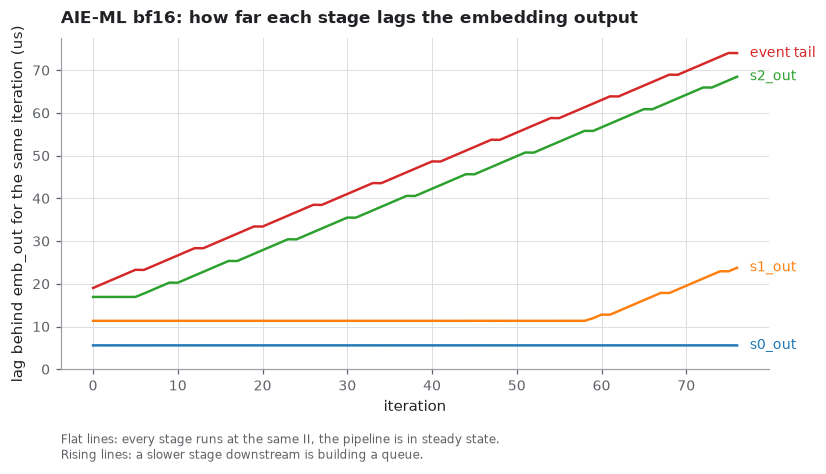

In [3]:
def frame_times_us(path):
    """End time of every TLAST frame, in us. Same T-marker rule as report.py."""
    out, now = [], None
    for line in Path(path).read_text(errors='replace').splitlines():
        s = line.strip()
        m = _TS.match(s)
        if m:
            now = int(m.group(1)) * _TO_NS[m.group(2).lower()] / 1e3
        elif 'TLAST' in s.upper():
            out.append(now)
    return np.array(out)

STAGE = {}
tabs = []
for P in PRECISIONS:
    ports = aie_io.load_ports(AIE / f'aie_pipeline_{P}.json')
    extra = [p for plist in ports['outputs'].values() for p in plist]
    names = {p.port: f'{t}' + ('' if len(plist) == 1 else f'[{i}]')
             for t, plist in ports['outputs'].items() for i, p in enumerate(plist)}
    T = {p: frame_times_us(SIM[P]['simd'] / 'data' / f'y_p{p}.txt') for p in sorted(names)}
    STAGE[P] = (names, T)
    it = np.arange(len(T[0]))
    for p, t in T.items():
        iv = np.diff(t) * 1e3
        tabs.append(dict(precision=P, port=f'y_p{p}', tensor=names[p], first_frame_us=round(t[0], 2),
                         ii_ns_it0_20=round(iv[:20].mean(), 1), ii_ns_it20_end=round((t[-1] - t[20]) / (len(t) - 21) * 1e3, 1),
                         lag_vs_emb_it0_us=round(t[0] - T[0][0], 2), lag_vs_emb_last_us=round(t[-1] - T[0][-1], 2)))
TAB_STAGE = pd.DataFrame(tabs)
display(TAB_STAGE)

for P in PRECISIONS:
    names, T = STAGE[P]
    fig, ax = plt.subplots(figsize=(7.4, 4.2))
    tail = max(names)
    ends = []
    for p, lab in ((2, 's0_out'), (4, 's1_out'), (6, 's2_out'), (tail, 'event tail')):
        lag = T[p] - T[0]
        ln, = ax.plot(lag, lw=1.6)
        ends.append((lag[-1], lab, ln.get_color(), len(lag) - 1))
    # End labels, pushed apart where lines converge (s2_out and the tail sit ~1.5 us apart in fp32).
    top = max(e[0] for e in ends)
    gap, placed = 0.06 * top, []
    for y, lab, col, x in sorted(ends, reverse=True):
        yl = min(y, placed[-1] - gap) if placed else y
        placed.append(yl)
        ax.annotate(lab, (x, y), xytext=(x + 1.5, yl), textcoords='data',
                    color=col, fontsize=9, va='center', annotation_clip=False)
    style(ax, f'AIE-ML {P}: how far each stage lags the embedding output',
          'iteration', 'lag behind emb_out for the same iteration (us)',
          'Flat lines: every stage runs at the same II, the pipeline is in steady state.\n'
          'Rising lines: a slower stage downstream is building a queue.')
    ax.set_ylim(bottom=0)
    save(fig, f'timing_stage_lag_{P}.png'); plt.show()

## 3. AIE: what sets the II — the slowest kernel

`aiesimulator --profile` counts processor cycles per call for every kernel. At the AIE-ML core
clock (read from the `.xpe`), cycles × period is the time one call takes. In a pipeline, **the
slowest kernel sets the II** of everything behind it — and, once the queues fill, in front of it.

One caveat on reading this table: a kernel that is blocked by a slow neighbour *inside its own
`run()`* (on a cascade stream) accumulates cycles while it waits. Its **min** is its compute; its
avg includes the wait. The fp32 kernels have min ≈ avg; the bf16 back-end kernels do not.

In [4]:
_PROW = re.compile(r'^\s+(\d+)\s+(\d+)\s+[\d.]+%\s+(\d+|-)\s+(\d+|-)\s+(\d+|-)\s+(\d+)\s+[\d.]+%'
                   r'\s+(\d+|-)\s+(\d+|-)\s+(\d+|-)\s+\S+\s+\S+\s+\S+\s+(\S+)\s+(\S+)')
_KIND = re.compile(r'(dense_single|dense_first|dense_middle|dense_last|roll_concat_batch|track_accum)')

def core_period_ns(xpe):
    m = re.search(r'clk_freq="(\d+(?:\.\d+)?)"', Path(xpe).read_text())
    return 1e3 / float(m.group(1))

def load_profiles(P):
    ns = core_period_ns(SIM[P]['xpe'])
    out = {}
    for f in sorted(SIM[P]['simd'].glob('profile_funct_*.txt')):
        lines = f.read_text(errors='replace').splitlines()
        tile = f.stem.split('profile_funct_')[1]          # col_row, as the VCD event list numbers them
        for ln in lines:
            m = _PROW.match(ln)
            if not m:
                continue
            calls, _, _, _, _, _, mn, avg, mx, fn, mangled = m.groups()
            k = _KIND.search(mangled + ' ' + fn)
            if not k or calls == '0':
                continue
            cfg = re.search(r'(L\d+Cfg)', mangled)
            out[(tile, k.group(1))] = dict(
                tile=tile, kernel=k.group(1), layer=LAYER.get(cfg.group(1), '') if cfg else '',
                calls=int(calls), ns_min=int(mn) * ns, ns_avg=int(avg) * ns, ns_max=int(mx) * ns)
    return pd.DataFrame(out.values()), ns

PROF = {}
for P in PRECISIONS:
    df, ns = load_profiles(P)
    PROF[P] = df
    print(f'{P}: {len(df)} kernels profiled, core period {ns:.3f} ns')
    display(df.sort_values('ns_avg', ascending=False).head(6).round(0))

fp32: 69 kernels profiled, core period 0.800 ns


,tile,kernel,layer,calls,ns_min,ns_avg,ns_max
37,18_3,dense_middle,s2_d0,77,4126.0,4154.0,4780.0
36,18_2,dense_middle,s2_d0,77,4126.0,4154.0,4780.0
68,9_4,dense_middle,s0_d0,77,4145.0,4153.0,4781.0
21,14_5,dense_middle,s1_d0,77,4130.0,4153.0,4780.0
67,9_3,dense_middle,s0_d0,77,4145.0,4153.0,4781.0
20,14_4,dense_middle,s1_d0,77,4130.0,4153.0,4780.0


bf16: 69 kernels profiled, core period 0.800 ns


,tile,kernel,layer,calls,ns_min,ns_avg,ns_max
52,25_0,track_accum,,77,878.0,1629.0,1754.0
49,23_3,dense_first,s2_d3,77,444.0,1449.0,1722.0
48,23_2,dense_first,s2_d3,77,444.0,1449.0,1722.0
45,22_1,dense_first,s2_d2,77,444.0,1285.0,1722.0
44,22_0,dense_first,s2_d2,77,444.0,1285.0,1722.0
38,19_0,dense_first,s2_d1,77,444.0,1121.0,1727.0


## 4. AIE: latency, read from the VCD

The VCD event list (`vcdanalyze --text`) records every program-counter change on every tile.
Two tiles bound the pipeline:

- **input**: the embedding kernel `dense_single<L1Cfg>::run` — its entry is the moment an
  iteration's 8 tracks start being computed;
- **output**: `track_accum` — its return is the moment that iteration's contribution to the
  event mean exists.

Tile coordinates come from the profiles above, not from the placement constraints. The multi-GB
event lists are scanned once and cached under `analysis/out/timing_cache/`.

##### fp32
  II at input  (emb_d0 start -> start, it 20..):   4172.0 ns
  II at output (track_accum done -> done)       :   4172.0 ns
  track_accum call, from the VCD                :   1760.8 ns median
  iteration latency, it 0 / 20 / last           : 89.15 / 88.37 / 88.37 us
  event latency (first track in -> mean out)    : 113.4  113.4  113.4  113.4  113.4  113.4  113.4  113.4  113.4  113.4  113.4  us  (event 0 is the flush)
  [PASS] fp32: output II from VCD vs PLIO tail II: 4,172 vs 4,172 (+0.00%, tolerance 0.5%)
##### bf16
  II at input  (emb_d0 start -> start, it 20..):    924.8 ns
  II at output (track_accum done -> done)       :   1650.1 ns
  track_accum call, from the VCD                :   1754.4 ns median
  iteration latency, it 0 / 20 / last           : 21.45 / 35.83 / 76.44 us
  event latency (first track in -> mean out)    : 31.2  36.3  41.4  46.5  51.5  56.6  61.7  66.8  71.8  76.9  82.0  us  (event 0 is the flush)
  [PASS] bf16: output II from VCD vs PLIO tail II: 1,650

  wrote analysis/out/timing_event_latency_aie.png


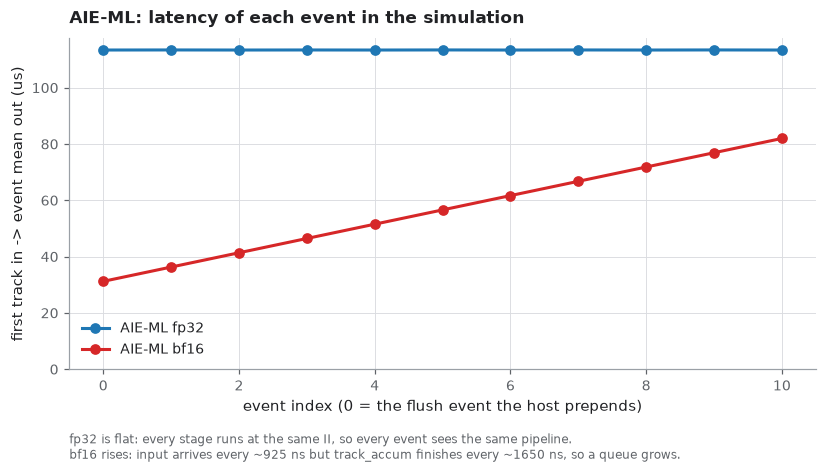

In [5]:
def vcd_bounds(P):
    prof = PROF[P]
    t_in  = prof[prof['layer'] == 'emb_d0']['tile'].iloc[0]
    t_acc = prof[prof['kernel'] == 'track_accum']['tile'].iloc[0]
    ev = SIM[P]['events']
    cache = CACHE / f'vcd_bounds_{P}_ev{SIM_EVENTS}.csv'
    if not cache.exists() or cache.stat().st_mtime < ev.stat().st_mtime:
        (ci, ri), (ca, ra) = t_in.split('_'), t_acc.split('_')
        # -a: the event list contains non-text bytes, and without it grep prints
        # "Binary file matches" instead of the lines.
        cmd = (f"LC_ALL=C grep -a -E 'event=PC_CHANGE,col=({ci}|{ca}),row=({ri}|{ra}),' '{ev}'"
               f" | LC_ALL=C grep -a -E 'info=(dense_single<L1Cfg>::run.*\\+0|track_accum.*\\+0|_main\\+[0-9]+)$'")
        rows = []
        for ln in subprocess.run(['bash', '-c', cmd], capture_output=True, text=True, errors='replace').stdout.splitlines():
            f = dict(kv.split('=', 1) for kv in ln.split(',')[:4])
            tile, info = f"{f['col']}_{f['row']}", ln.split('info=', 1)[1]
            if tile == t_in and info.startswith('dense_single'):
                rows.append(('in', int(f['time'])))
            elif tile == t_acc and info.startswith('track_accum'):
                rows.append(('acc_in', int(f['time'])))
            elif tile == t_acc and info.startswith('_main+'):
                rows.append(('main', int(f['time'])))
        pd.DataFrame(rows, columns=['kind', 'time_ps']).to_csv(cache, index=False)
    d = pd.read_csv(cache)
    t_in_ = d[d.kind == 'in'].time_ps.to_numpy() / 1e6
    acc_in = d[d.kind == 'acc_in'].time_ps.to_numpy() / 1e6
    main = np.sort(d[d.kind == 'main'].time_ps.to_numpy() / 1e6)
    acc_out = main[np.searchsorted(main, acc_in, side='right')]   # first return to main after each entry
    n = SIM[P]['iterations']
    assert len(t_in_) == len(acc_in) == n, f'{P}: {len(t_in_)} input / {len(acc_in)} accum calls, expected {n}'
    return t_in_, acc_in, acc_out

LAT = {}
for P in PRECISIONS:
    t_in, acc_in, acc_out = vcd_bounds(P)
    n = len(t_in)
    k = np.arange(n // ITER_PER_EVENT)
    first, last = ITER_PER_EVENT * k, ITER_PER_EVENT * k + ITER_PER_EVENT - 1
    LAT[P] = dict(
        t_in=t_in, acc_in=acc_in, acc_out=acc_out,
        ii_in_ns=np.diff(t_in)[20:].mean() * 1e3,
        ii_out_ns=np.diff(acc_out)[20:].mean() * 1e3,
        iter_lat=acc_out - t_in,                                  # one iteration, in -> out
        event_lat=acc_out[last] - t_in[first],                    # an event: first track in -> mean out
        board1_dev=acc_out[2 * ITER_PER_EVENT - 1] - t_in[0],     # what a 1-event board call runs: flush + 1 event
        accum_ns=np.median(acc_out - acc_in) * 1e3)
    L = LAT[P]
    print(f'##### {P}')
    print(f'  II at input  (emb_d0 start -> start, it 20..): {L["ii_in_ns"]:8.1f} ns')
    print(f'  II at output (track_accum done -> done)       : {L["ii_out_ns"]:8.1f} ns')
    print(f'  track_accum call, from the VCD                : {L["accum_ns"]:8.1f} ns median')
    print(f'  iteration latency, it 0 / 20 / last           : {L["iter_lat"][0]:.2f} / {L["iter_lat"][20]:.2f} / {L["iter_lat"][-1]:.2f} us')
    print(f'  event latency (first track in -> mean out)    : ' + '  '.join(f'{x:.1f}' for x in L['event_lat']) + '  us  (event 0 is the flush)')
    tail = max(STAGE[P][0])
    check(f'{P}: output II from VCD vs PLIO tail II', L['ii_out_ns'],
          (STAGE[P][1][tail][-1] - STAGE[P][1][tail][20]) / (n - 21) * 1e3, 0.005)

fig, ax = plt.subplots(figsize=(7.4, 4.2))
for P in PRECISIONS:
    ax.plot(LAT[P]['event_lat'], marker='o', color=COL[f'aie_{P}'], label=LABEL[f'aie_{P}'])
style(ax, 'AIE-ML: latency of each event in the simulation',
      'event index (0 = the flush event the host prepends)', 'first track in -> event mean out (us)',
      'fp32 is flat: every stage runs at the same II, so every event sees the same pipeline.\n'
      'bf16 rises: input arrives every ~925 ns but track_accum finishes every ~1650 ns, so a queue grows.')
ax.set_ylim(bottom=0); ax.legend()
save(fig, 'timing_event_latency_aie.png'); plt.show()

### Reading the AIE result

- **fp32** is in steady state. The II is the same at every stage and at the input, and it is set by
  the slowest kernels (the `dense_middle` cascade tiles of the three 256→128 solver layers).
  Latency is constant for every event.
- **bf16** is **not** in steady state after 77 iterations. Its dense layers are fast (the embedding
  sets a ~925 ns input interval) but `track_accum` — the kernel that averages the tracks — takes
  ~1.6 µs, so the output interval is ~1650 ns and a queue builds between them. The first event's
  latency is what an event arriving at an **idle** array sees; the latency under continuous load
  is higher and is not reached in this simulation.

In [6]:
for P in PRECISIONS:
    prof = PROF[P]
    slow = prof.sort_values('ns_avg', ascending=False).iloc[0]
    print(f'{P}: slowest kernel {slow.kernel} {slow.layer} on tile {slow.tile}: '
          f'{slow.ns_avg:.0f} ns/call avg ({slow.ns_min:.0f} min) vs output II {LAT[P]["ii_out_ns"]:.0f} ns')
check('fp32: slowest kernel ns/call vs output II', PROF['fp32']['ns_avg'].max(), LAT['fp32']['ii_out_ns'], 0.01)
ta = PROF['bf16'].query("kernel == 'track_accum'").iloc[0]
check('bf16: track_accum ns/call (VCD median) vs output II', LAT['bf16']['accum_ns'], LAT['bf16']['ii_out_ns'], 0.10)

fp32: slowest kernel dense_middle s2_d0 on tile 18_3: 4154 ns/call avg (4126 min) vs output II 4172 ns
bf16: slowest kernel track_accum  on tile 25_0: 1629 ns/call avg (878 min) vs output II 1650 ns
  [PASS] fp32: slowest kernel ns/call vs output II: 4,154 vs 4,172 (-0.44%, tolerance 1.0%)
  [PASS] bf16: track_accum ns/call (VCD median) vs output II: 1,754 vs 1,650 (+6.32%, tolerance 10.0%)


## 5. PL: latency and II from RTL co-simulation

The PL kernel is **not pipelined**: it finishes one track before starting the next. Its latency and
its II are therefore the same number. Two co-simulations (1 event and 10 events, one kernel call
each) separate the per-event cost from the fixed per-call cost.

In [7]:
mk = (REPO / 'pl_fixed' / 'Makefile').read_text()
PL_HZ = int(re.search(r'^KERNEL_FREQ\s*\?=\s*(\d+)', mk, re.M).group(1))
PL_NS = 1e9 / PL_HZ

per_event_cyc = (COSIM[10] - COSIM[1]) / 9
fixed_cyc = COSIM[1] - per_event_cyc
PL_DEV_US_EVENT = per_event_cyc * PL_NS / 1e3

# ---------------------------------------------------------------------------
# The csynth cross-check, read TWO ways.
#
# The kernel is a DATAFLOW region now, and a dataflow report HAS NO LOOP TABLE
# -- it prints `* Loop: N/A`, because the loops live inside the concurrent
# processes instead of in the top-level schedule. There is no TrackLoop row to
# read. The per-track cost comes from the top-level Latency Summary instead,
# whose Interval column is evaluated at the two ends of the event loop's
# LOOP_TRIPCOUNT:
#
#   |  Latency (cycles)  | Latency (absolute) |     Interval      | Pipeline |
#   |    51919|  51552417|  0.288 ms|  0.286 s|  51504|  51552002 | dataflow |
#
# so the SLOPE between interval min and max is the per-event interval. The old
# sequential report had a TrackLoop row and no meaningful Interval; both are
# read below, so this notebook still runs against an archived pre-dataflow
# report -- which matters, because results/pl_fixed/baseline_*/ is exactly one.
# ---------------------------------------------------------------------------
rpt = (REPO / 'pl_fixed/rtda_split_hls/solution1/syn/report/rtda_split_top_csynth.rpt').read_text(errors='replace')
src = (REPO / 'pl_fixed/pl/src/rtda_split_top.cpp').read_text(errors='replace')

def _csynth_per_track():
    """(cycles/track, cycles/event, how it was read), either report layout."""
    row = next((l for l in rpt.splitlines() if re.search(r'[-+] TrackLoop\b', l)), None)
    if row is not None:                       # sequential: the Loop table
        lo, hi = (int(x) for x in re.search(r'(\d+)\s*~\s*(\d+)', row.split('|')[4]).groups())
        return hi, hi * TRACKS_PER_EVENT, f'TrackLoop {lo:,}~{hi:,}'
    ev = re.search(r'LOOP_TRIPCOUNT min=(\d+) max=(\d+)', src)   # dataflow: the slope
    ev_lo, ev_hi = int(ev.group(1)), int(ev.group(2))
    lat = next(l for l in rpt.splitlines()
               if l.strip().startswith('|') and len(l.split('|')) == 9
               and l.split('|')[1].strip().isdigit() and l.split('|')[7].strip().isalpha())
    f = [x.strip() for x in lat.split('|')]
    per_ev = (int(f[6]) - int(f[5])) / (ev_hi - ev_lo)
    return (per_ev / TRACKS_PER_EVENT, per_ev,
            f"{f[7]} interval {int(f[5]):,}..{int(f[6]):,} over {ev_lo}..{ev_hi} events")

csy_track, csy_event, csy_how = _csynth_per_track()

print(f'clock           : {PL_HZ/1e6:.0f} MHz ({PL_NS:.4f} ns), from pl_fixed/Makefile KERNEL_FREQ')
print(f'cosim 1 event   : {COSIM[1]:>10,} cycles')
print(f'cosim 10 events : {COSIM[10]:>10,} cycles')
print(f'  per event     : {per_event_cyc:>12,.0f} cycles = {PL_DEV_US_EVENT:8.1f} us')
print(f'  per track     : {per_event_cyc/TRACKS_PER_EVENT:>12,.0f} cycles = {PL_DEV_US_EVENT/TRACKS_PER_EVENT:8.2f} us')
print(f'  fixed per call: {fixed_cyc:>12,.0f} cycles   (pipeline fill + AXI latency)')
print(f'csynth estimate : {csy_track:,.0f} cycles/track, {csy_event:,.0f} cycles/event')
print(f'                  [{csy_how}]')


clock           : 180 MHz (5.5556 ns), from pl_fixed/Makefile KERNEL_FREQ
cosim 1 event   :     68,981 cycles
cosim 10 events :    532,949 cycles
  per event     :       51,552 cycles =    286.4 us
  per track     :        1,031 cycles =     5.73 us
  fixed per call:       17,429 cycles   (pipeline fill + AXI latency)
csynth estimate : 1,031 cycles/track, 51,552 cycles/event
                  [dataflow interval 51,504..51,552,002 over 1..1000 events]


## 6. The board: how much the host adds

Rows are the same ones `rtda_scan.ipynb` compares across implementations (AIE `mode=gmio,
launches=1`; PL `mode=single`). For each, the device-only time for **the same work** comes from
§4 and §5:

- a 1-event AIE board call runs **two** events through the array — the host prepends a flush
  event — so its device time is the simulated time from the flush's first track to the real event's mean;
- at 10,000 events the device time per event is `ITER_PER_EVENT × II`, the sustained rate.

,impl,events,device,launch_and_wait,xrt_sync,host_staging,us_total,host_share_%
0,aie_fp32,1,142.63,374.00,33.44,3.26,553.33,74.22
1,aie_fp32,10000,29.21,0.93,0.01,1.42,31.56,7.46
2,aie_bf16,1,42.77,209.98,32.19,3.29,288.23,85.16
3,aie_bf16,10000,11.55,0.37,0.01,1.67,13.60,15.05
4,pl_fixed,1,383.23,37.72,6.84,7.99,435.78,12.06
5,pl_fixed,10000,286.41,0.01,0.00,4.88,291.30,1.68


  [PASS] aie_fp32: device 7xII vs board us_kernel/event @ 10,000 events: 29.21 vs 30.13 (-3.07%, tolerance 5.0%)
  [PASS] aie_bf16: device 7xII vs board us_kernel/event @ 10,000 events: 11.55 vs 11.92 (-3.09%, tolerance 5.0%)
  [PASS] pl_fixed: cosim per event vs board us_kernel/event @ 10,000 events: 286.4 vs 286.4 (-0.01%, tolerance 0.1%)


  wrote analysis/out/timing_host_split_1ev.png


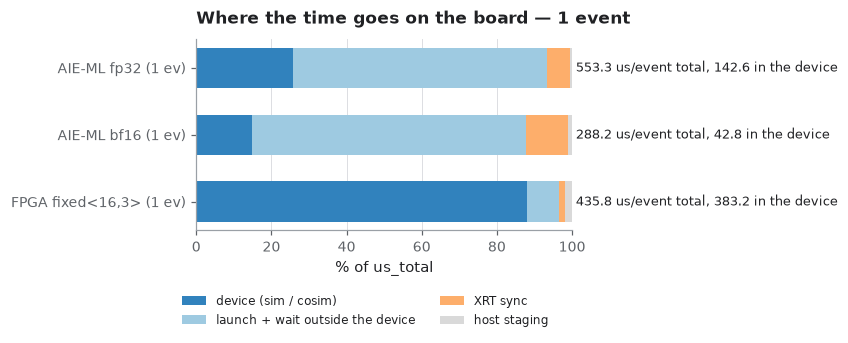

  wrote analysis/out/timing_host_split_batch.png


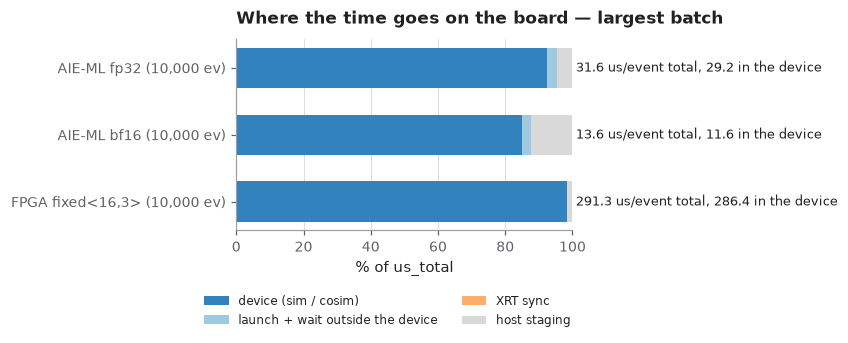

In [8]:
def load_hw(impl):
    d = RESULTS / impl / 'hw'
    df = pd.read_csv(d / 'scan.csv')
    keep = (df['mode'] == 'gmio') & (df['launches'] == 1) if impl.startswith('aie') else (df['mode'] == 'single')
    df = df[keep & (df['events'] > 0)]
    g = df.groupby('events')[['us_total', 'us_execute', 'us_kernel']].median()
    return g.div(g.index.to_series(), axis=0)                   # per event

HW = {impl: load_hw(impl) for impl in IMPLS if (RESULTS / impl / 'hw' / 'scan.csv').exists()}

def device_us(impl, events):
    if impl == 'pl_fixed':
        return (fixed_cyc + events * per_event_cyc) * PL_NS / 1e3 / events
    L = LAT[impl.split('_')[1]]
    if events == 1:
        return L['board1_dev']
    return (events + 1) * ITER_PER_EVENT * L['ii_out_ns'] / 1e3 / events

split = []
for impl, g in HW.items():
    for ev in (1, int(g.index.max())):
        r = g.loc[ev]
        dev = device_us(impl, ev)
        split.append(dict(impl=impl, events=ev, device=dev, launch_and_wait=r.us_kernel - dev,
                          xrt_sync=r.us_execute - r.us_kernel, host_staging=r.us_total - r.us_execute,
                          us_total=r.us_total))
SPLIT = pd.DataFrame(split)
SPLIT['host_share_%'] = 100 * (SPLIT.us_total - SPLIT.device) / SPLIT.us_total
display(SPLIT.round(2))

for impl in ('aie_fp32', 'aie_bf16'):
    ev = int(HW[impl].index.max())
    check(f'{impl}: device 7xII vs board us_kernel/event @ {ev:,} events',
          device_us(impl, ev), HW[impl].loc[ev].us_kernel, 0.05)
check('pl_fixed: cosim per event vs board us_kernel/event @ 10,000 events',
      PL_DEV_US_EVENT, HW['pl_fixed'].loc[10000].us_kernel, 0.001)

PARTS = [('device', 'device (sim / cosim)', '#3182bd'), ('launch_and_wait', 'launch + wait outside the device', '#9ecae1'),
         ('xrt_sync', 'XRT sync', '#fdae6b'), ('host_staging', 'host staging', '#d9d9d9')]
for ev_tag in ('1 event', 'largest batch'):
    sub = SPLIT[SPLIT.events == 1] if ev_tag == '1 event' else SPLIT.loc[SPLIT.groupby('impl').events.idxmax()]
    sub = sub.set_index('impl').loc[[i for i in IMPLS if i in set(sub.impl)]].reset_index()
    fig, ax = plt.subplots(figsize=(7.6, 3.0))
    y = np.arange(len(sub))[::-1]
    left = np.zeros(len(sub))
    for key, lab, col in PARTS:
        w = (100 * sub[key].clip(lower=0) / sub.us_total).to_numpy()
        ax.barh(y, w, left=left, color=col, label=lab, height=0.6)
        left += w
    for yi, (_, r) in zip(y, sub.iterrows()):
        ax.text(101, yi, f'{r.us_total:,.1f} us/event total, {r.device:,.1f} in the device', va='center', fontsize=8.5)
    ax.set_yticks(y, [f'{LABEL[i]} ({e:,} ev)' for i, e in zip(sub.impl, sub.events)])
    ax.set_xlim(0, 100); ax.grid(axis='y', visible=False)
    style(ax, f'Where the time goes on the board — {ev_tag}', '% of us_total', None)
    ax.legend(loc='upper center', bbox_to_anchor=(0.45, -0.28), ncol=2, fontsize=8)
    save(fig, f'timing_host_split_{"1ev" if ev_tag == "1 event" else "batch"}.png'); plt.show()

## 7. The CPU and GPU baselines

No device boundary, so no device-only number: the call **is** the computation. Latency is the
1-event call; throughput is taken at the CPU's largest batch and at the GPU's **best** point,
which is not its largest batch (see `rtda_scan.ipynb` §8 and `CLAUDE.md`).

In [9]:
def per_event(df):
    g = df.groupby('events')['us_execute'].median()
    return g / g.index

BASE = []
CPU = pd.read_csv(RESULTS / 'cpu/native/scan.csv') if (RESULTS / 'cpu/native/scan.csv').exists() else pd.DataFrame()
if not CPU.empty:
    CPU['threads'] = CPU['variant'].str.rsplit('_t', n=1).str[-1].astype(int)
    for n in (1, 8, 32):
        s = per_event(CPU[CPU.threads == n])
        BASE.append(dict(name=f'CPU fp32 {n}T', key=('cpu', n), lat_us=s.loc[1], thr_us=s.iloc[-1], thr_at=int(s.index[-1])))
GPU = pd.read_csv(RESULTS / 'gpu/native/scan.csv') if (RESULTS / 'gpu/native/scan.csv').exists() else pd.DataFrame()
GPU_META = read_kv(RESULTS / 'gpu/native/scan_meta.txt')
if not GPU.empty:
    GPU = GPU[~GPU['notes'].fillna('').str.contains('SMOKE TEST', case=False)]
    for v in ('fp32', 'bf16'):
        s = per_event(GPU[(GPU.variant == v) & (GPU['mode'] == 'single')])
        BASE.append(dict(name=f'GPU {v} ({GPU_META.get("gpu_model", "?")})', key=('gpu', v), lat_us=s.loc[1],
                         thr_us=s.min(), thr_at=int(s.idxmin())))
BASE = pd.DataFrame(BASE)
display(BASE.drop(columns='key').round(2))

,name,lat_us,thr_us,thr_at
0,CPU fp32 1T,465.02,305.55,10000
1,CPU fp32 8T,510.26,40.03,10000
2,CPU fp32 32T,495.82,16.31,10000
3,GPU fp32 (NVIDIA L40S),624.04,2.54,500
4,GPU bf16 (NVIDIA L40S),597.22,0.99,1000


## 8. The comparison

One table for the architectures (device only), one row set for what the board delivers, and one
figure that puts latency and throughput on separate axes — because on a pipelined design they are
different numbers.

,implementation,measured by,II,throughput (us/event),"latency, 1 event (us)",pipeline depth (iterations),board us/event @1 / @10k
0,AIE-ML fp32,aiesimulator + VCD,"4,172 ns / 8 tracks",29.2,113.4,21.2,550 / 30.1
1,AIE-ML bf16,aiesimulator + VCD,"1,650 ns / 8 tracks",11.6,"31.2 idle, rising",13+,285 / 11.9
2,"FPGA fixed<16,3>",RTL cosim,5.7 us / track,286.4,383.2,16.9,428 / 286.4
3,CPU fp32 1T,host wall-clock,-,"305.55 @ 10,000 ev",465.0,-,-
4,CPU fp32 8T,host wall-clock,-,"40.03 @ 10,000 ev",510.3,-,-
5,CPU fp32 32T,host wall-clock,-,"16.31 @ 10,000 ev",495.8,-,-
6,GPU fp32 (NVIDIA L40S),host wall-clock,-,2.54 @ 500 ev,624.0,-,-
7,GPU bf16 (NVIDIA L40S),host wall-clock,-,"0.99 @ 1,000 ev",597.2,-,-


  wrote analysis/out/timing_latency_vs_throughput.png


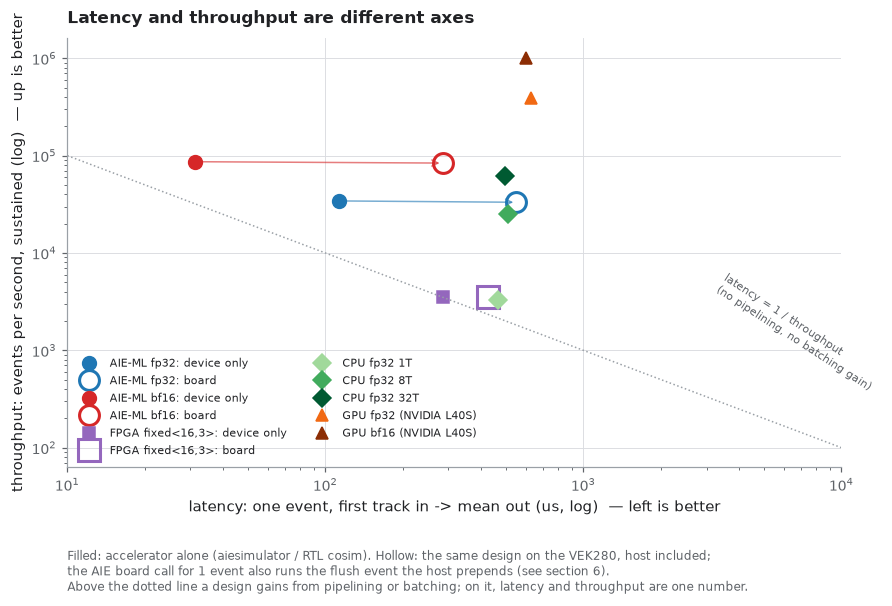

In [10]:
summ = []
for P in PRECISIONS:
    L, impl = LAT[P], f'aie_{P}'
    summ.append({'implementation': LABEL[impl], 'measured by': 'aiesimulator + VCD',
                 'II': f"{L['ii_out_ns']:,.0f} ns / 8 tracks",
                 'throughput (us/event)': round(ITER_PER_EVENT * L['ii_out_ns'] / 1e3, 1),
                 'latency, 1 event (us)': round(L['event_lat'][1], 1) if P == 'fp32' else f"{L['event_lat'][0]:.1f} idle, rising",
                 'pipeline depth (iterations)': round(L['iter_lat'][-1] / (L['ii_out_ns'] / 1e3), 1) if P == 'fp32' else f"{L['iter_lat'][0] / (L['ii_out_ns'] / 1e3):.0f}+",
                 'board us/event @1 / @10k': f"{HW[impl].loc[1].us_execute:,.0f} / {HW[impl].iloc[-1].us_execute:,.1f}"})
# Throughput and latency are no longer the same number. They were, while the
# kernel ran one track through all fourteen dense layers before starting the
# next: nothing overlapped, so an event cost exactly its own latency and the
# pipeline depth was 1. The kernel is a dataflow pipeline now, so a call pays
# a fill ONCE (fixed_cyc, measured as the intercept of the 1-vs-10-event cosim
# pair) and then retires an event every per_event_cyc. Both are read from the
# same two cosim runs; neither is assumed.
summ.append({'implementation': LABEL['pl_fixed'], 'measured by': 'RTL cosim',
             'II': f"{PL_DEV_US_EVENT / TRACKS_PER_EVENT:,.1f} us / track",
             'throughput (us/event)': round(PL_DEV_US_EVENT, 1),
             'latency, 1 event (us)': round(COSIM[1] * PL_NS / 1e3, 1),
             'pipeline depth (iterations)': round(fixed_cyc / (per_event_cyc / TRACKS_PER_EVENT), 1),
             'board us/event @1 / @10k': f"{HW['pl_fixed'].loc[1].us_execute:,.0f} / {HW['pl_fixed'].iloc[-1].us_execute:,.1f}"})
for _, b in BASE.iterrows():
    summ.append({'implementation': b['name'], 'measured by': 'host wall-clock', 'II': '-',
                 'throughput (us/event)': f"{b.thr_us:.2f} @ {b.thr_at:,} ev", 'latency, 1 event (us)': round(b.lat_us, 1),
                 'pipeline depth (iterations)': '-', 'board us/event @1 / @10k': '-'})
SUMMARY = pd.DataFrame(summ)
display(SUMMARY)

fig, ax = plt.subplots(figsize=(8.0, 5.4))
for P in PRECISIONS:
    impl, L = f'aie_{P}', LAT[P]
    dev = (L['event_lat'][1] if P == 'fp32' else L['event_lat'][0], 1e6 / (ITER_PER_EVENT * L['ii_out_ns'] / 1e3))
    brd = (HW[impl].loc[1].us_execute, 1e6 / HW[impl].iloc[-1].us_execute)
    ax.annotate('', xy=brd, xytext=dev, arrowprops=dict(arrowstyle='->', color=COL[impl], lw=1, alpha=0.6))
    ax.plot(*dev, 'o', color=COL[impl], ms=9, label=f'{LABEL[impl]}: device only')
    ax.plot(*brd, 'o', mfc='none', mec=COL[impl], mew=2, ms=13, label=f'{LABEL[impl]}: board')
dev = (PL_DEV_US_EVENT, 1e6 / PL_DEV_US_EVENT)
brd = (HW['pl_fixed'].loc[1].us_execute, 1e6 / HW['pl_fixed'].iloc[-1].us_execute)
# The PL's two points nearly coincide (the host adds ~1%), so the board marker is
# drawn hollow and larger: the filled device marker must stay visible inside it.
ax.plot(*dev, 's', color=COL['pl_fixed'], ms=8, label=f"{LABEL['pl_fixed']}: device only")
ax.plot(*brd, 's', mfc='none', mec=COL['pl_fixed'], mew=2, ms=14, label=f"{LABEL['pl_fixed']}: board")
for _, b in BASE.iterrows():
    col = CPU_SHADE[b.key[1]] if b.key[0] == 'cpu' else GPU_SHADE[b.key[1]]
    ax.plot(b.lat_us, 1e6 / b.thr_us, '^' if b.key[0] == 'gpu' else 'D', color=col, ms=8, label=b['name'])
lo, hi = 10, 1e4
xs = np.logspace(1, 4, 50)
ax.plot(xs, 1e6 / xs, ls=':', color='#9aa0a6', lw=1)
ax.text(3.2e3, 1e6 / 3.2e3 * 1.25, 'latency = 1 / throughput\n(no pipelining, no batching gain)', fontsize=7.5, color='#5f6368', rotation=-33)
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(lo, hi)
style(ax, 'Latency and throughput are different axes',
      'latency: one event, first track in -> mean out (us, log)  — left is better',
      'throughput: events per second, sustained (log)  — up is better',
      'Filled: accelerator alone (aiesimulator / RTL cosim). Hollow: the same design on the VEK280, host included;\n'
      'the AIE board call for 1 event also runs the flush event the host prepends (see section 6).\n'
      'Above the dotted line a design gains from pipelining or batching; on it, latency and throughput are one number.')
ax.legend(fontsize=7.5, loc='lower left', ncol=2)
save(fig, 'timing_latency_vs_throughput.png'); plt.show()

## 9. Checks, caveats, and what is not measured here

**Caveats**

- The AIE simulation builds drain four stage outputs to PLIO debug taps; the board runs the GMIO
  system build, which has none. The board agreeing with the simulated sustained rate to within a few
  percent (§6) is the evidence the taps do not set the II.
- bf16 does not reach steady state in 77 iterations (§4). Its latency under continuous load is
  not measured; the number quoted is for an event arriving at an idle array.
- The PLIO tail frames are offset from the kernel's 128-value blocks by one 4-value line — a framing
  artefact of the text output. Latency here is taken from the VCD, which does not have it.
- PL csynth is a worst-case estimate; cosim is the measurement.
- CPU and GPU numbers are host wall-clock on different machines; they have no "device only" column
  because they have no device boundary.

In [11]:
print('Cross-checks')
for name, got, want, tol, ok in CHECKS:
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
n_fail = sum(not c[-1] for c in CHECKS)
print(f'\n{len(CHECKS) - n_fail}/{len(CHECKS)} passed')

report = ['# RTDA timing summary', '', md_table(SUMMARY), '', '## Where the time goes on the board', '',
          md_table(SPLIT.round(2)), '', '## Figures', ''] + [f'- `analysis/out/{f}`' for f in FIGS]
(OUTD / 'timing_report.md').write_text('\n'.join(report) + '\n')
print('  wrote', (OUTD / 'timing_report.md').relative_to(REPO))

Cross-checks
  [PASS] fp32: output II from VCD vs PLIO tail II
  [PASS] bf16: output II from VCD vs PLIO tail II
  [PASS] fp32: slowest kernel ns/call vs output II
  [PASS] bf16: track_accum ns/call (VCD median) vs output II
  [PASS] aie_fp32: device 7xII vs board us_kernel/event @ 10,000 events
  [PASS] aie_bf16: device 7xII vs board us_kernel/event @ 10,000 events
  [PASS] pl_fixed: cosim per event vs board us_kernel/event @ 10,000 events

7/7 passed
  wrote analysis/out/timing_report.md
